In [1]:
import pandas as pd
dataset = pd.read_csv('../data/train.csv')

In [2]:
dataset.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
dataset.toxic.value_counts()

toxic
0    144277
1     15294
Name: count, dtype: int64

<Axes: title={'center': 'Class Distribution : Toxic vs Non-toxic'}, xlabel='toxic'>

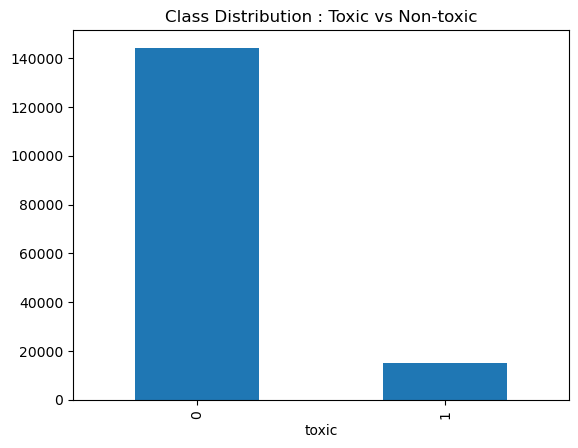

In [4]:
dataset.toxic.value_counts().plot(kind='bar', title = 'Class Distribution : Toxic vs Non-toxic')

In [5]:
def comment_text(text) :
    return len(text)
dataset['text_length'] = dataset['comment_text'].apply(comment_text)
dataset.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,text_length
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67


In [6]:
import seaborn as sns

<Axes: xlabel='text_length', ylabel='Count'>

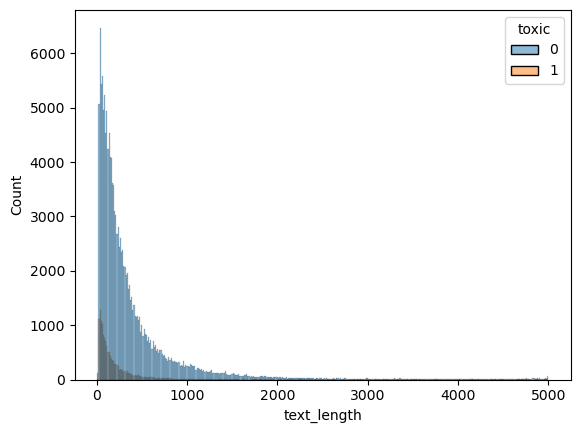

In [7]:
sns.histplot(data = dataset, x = 'text_length', hue = 'toxic')

In [8]:
dataset_contains_http = dataset[dataset['comment_text'].str.contains('http', regex=True, na=False)]
print(dataset_contains_http)

                      id                                       comment_text  \
22      000c0dfd995809fa  "\n\n Snowflakes are NOT always symmetrical! \...   
33      001363e1dbe91225  I was able to post the above list so quickly b...   
73      002c9cccf2f1d05b  "\n Ambiguous ? \nSo Mabuska Irish can mean mo...   
91      0038f191ffc93d75  Transliteration of Russian place names\nIn wri...   
101     003fa0c68deca750  Check the following websites:\n\nhttp://www.ir...   
...                  ...                                                ...   
159344  fc4f3715277260f3  jprw \n\nplease visit this link to better unde...   
159375  fca6db97dde470bc  "\n\nHello\nI keep getting a message from anot...   
159417  fd5773ec2e4bcf3a  "\n\n News suppressed on Wikipedia http://rexc...   
159418  fd58d3a74b75da85  "From their website:\n""In 1965 Rudolf Schenke...   
159508  ff1fd5721a58e8c7  Apparently Palit is found to be worthy of ment...   

        toxic  severe_toxic  obscene  threat  insul

In [9]:
dataset_contains_newline = dataset[dataset['comment_text'].str.contains('\n', regex=True, na=False)]
print(dataset_contains_newline)

                      id                                       comment_text  \
0       0000997932d777bf  Explanation\nWhy the edits made under my usern...   
3       0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...   
5       00025465d4725e87  "\n\nCongratulations from me as well, use the ...   
10      0005300084f90edc  "\nFair use rationale for Image:Wonju.jpg\n\nT...   
11      00054a5e18b50dd4  bbq \n\nbe a man and lets discuss it-maybe ove...   
...                  ...                                                ...   
159563  ffe029a7c79dc7fe  "\nplease identify what part of BLP applies be...   
159566  ffe987279560d7ff  ":::::And for the second time of asking, when ...   
159567  ffea4adeee384e90  You should be ashamed of yourself \n\nThat is ...   
159568  ffee36eab5c267c9  Spitzer \n\nUmm, theres no actual article for ...   
159570  fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   

        toxic  severe_toxic  obscene  threat  insul

In [10]:
dataset_contains_spaces = dataset[dataset['comment_text'].str.contains('   ', regex=True, na=False)]
print(dataset_contains_spaces)

                      id                                       comment_text  \
23      000c6a3f0cd3ba8e  "\n\n The Signpost: 24 September 2012 \n\n Rea...   
24      000cfee90f50d471  "\n\nRe-considering 1st paragraph edit?\nI don...   
27      000ffab30195c5e1  Yes, because the mother of the child in the ca...   
29      0010833a96e1f886  "== A barnstar for you! ==\n\n  The Real Life ...   
35      00148d055a169b93  "\n\nNot at all, you are making a straw man ar...   
...                  ...                                                ...   
159545  ffb268f37788a011  , 7 March 2011 (UTC)\nAre you also User:Bmatts...   
159560  ffcdcb71854f6d8a  "Editing of article without Consensus & Remova...   
159562  ffd72e9766c09c97  "\n Auto guides and the motoring press are not...   
159566  ffe987279560d7ff  ":::::And for the second time of asking, when ...   
159570  fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   

        toxic  severe_toxic  obscene  threat  insul

In [11]:
import re
dataset_contains_caps = dataset[dataset['comment_text'].str.contains(r"\b[A-Z]{3,}\b", regex=True, na=False)]
print(dataset_contains_caps)

                      id                                       comment_text  \
0       0000997932d777bf  Explanation\nWhy the edits made under my usern...   
1       000103f0d9cfb60f  D'aww! He matches this background colour I'm s...   
6       0002bcb3da6cb337       COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK   
10      0005300084f90edc  "\nFair use rationale for Image:Wonju.jpg\n\nT...   
12      0005c987bdfc9d4b  Hey... what is it..\n@ | talk .\nWhat is it......   
...                  ...                                                ...   
159551  ffbc2db4225258dd  While about half the references are from BYU-I...   
159555  ffc2f409658571f1  "\n\nHow come when you download that MP3 it's ...   
159556  ffc671f2acdd80e1  I'll be on IRC, too, if you have a more specif...   
159563  ffe029a7c79dc7fe  "\nplease identify what part of BLP applies be...   
159564  ffe897e7f7182c90  Catalan independentism is the social movement ...   

        toxic  severe_toxic  obscene  threat  insul

In [13]:
dataset_contains_punctuations = dataset[dataset['comment_text'].str.contains(r"([^\w\s])\1{2,}", regex=True, na=False)]
print(dataset_contains_punctuations)

/var/folders/2v/86_f8qdj0nld18dgy92gvql80000gn/T/ipykernel_78738/1865407977.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dataset_contains_punctuations = dataset[dataset['comment_text'].str.contains(r"([^\w\s])\1{2,}", regex=True, na=False)]


                      id                                       comment_text  \
12      0005c987bdfc9d4b  Hey... what is it..\n@ | talk .\nWhat is it......   
20      000b08c464718505  "\n\n Regarding your recent edits \n\nOnce aga...   
42      001810bf8c45bf5f  You are gay or antisemmitian? \n\nArchangel WH...   
44      001956c382006abd  I'm Sorry \n\nI'm sorry I screwed around with ...   
48      001cadfd324f8087  "\nAs for your claims of ""stalking"", that is...   
...                  ...                                                ...   
159542  ffa95244f261527f  maybe he's got better things to do than spend ...   
159546  ffb47123b2d82762  "\n\nHey listen don't you ever!!!! Delete my e...   
159560  ffcdcb71854f6d8a  "Editing of article without Consensus & Remova...   
159566  ffe987279560d7ff  ":::::And for the second time of asking, when ...   
159570  fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   

        toxic  severe_toxic  obscene  threat  insul

In [14]:
dataset_contains_htmltags = dataset[dataset['comment_text'].str.contains('<', na=False)]
print(dataset_contains_htmltags)

                      id                                       comment_text  \
661     01cbab2392e63259  "\n\n Wikipedia:Articles for deletion/Cheongye...   
3840    0a3ae987022ad45d  "\nBut Stranger Danger is so fun (. Good luck ...   
5335    0e343b7f449df75a  Don't vandalize other wikipedians pages. 2nd w...   
5385    0e5c33beed23fb7c                         Julie<3 \n\nSummer Lovin<3   
6844    124393865070fe4d  Testing\nThanks for experimenting with the pag...   
...                  ...                                                ...   
157976  e6c80bbefa386e8e  UFC 82\n\nSeriously > Tuckdogg Faggot < ... st...   
158119  e910cdb6332c673f  think you are a double headed breast!!!!!!!!!!...   
158173  e9e45f79d94fd41f  "\n\n Comment tags \n\nyou have NO message...b...   
158463  ee49b6ac10638687  "\n\n non-NPOV + inaccurate information \n\nRe...   
159330  fc34b4d6472ab29d                  I LOVE KATILYN JEWELL!!!! <333333   

        toxic  severe_toxic  obscene  threat  insul

In [15]:
# Noise audit findings:
# - 139 comments contain URLs (http)
# - 2943 comments contain newlines (\n)
# - 0 proper HTML tags found in sample (2 stray '<' chars, non-HTML usage)
# - 1441 comments contain all-caps words
# - 636 comments contain repeated punctuation
# Note: HTML tags may appear in full 159k dataset but not in this 5k sample

In [16]:
# Edge cases to test every cleaning function built. 
# Covered: URLs, HTML tags, newlines, all-caps, repeated punctuation, empty 
# string, only spaces, mixed noise, AAVE phrasing, sarcasm, and emoji.

str1 = "hey, there! checkout the major discount ever on shoes!!! visit : https://www.shoepoint.com First come, first serve service."
str2 = "Html is a very easy to learn language, the building blocks of it are its tags such as </head> <body> <p> <br> and many more."
str3 = "Smriti this side.\n Building her first ever END TO END deployed project.\n\n Thankyou."
str4 = "WHAT THEE HELLLL? HOW CAN SOMEONE DO THIS????"
str5 = "I'm so excited to meet you this weekend,,, gonna have a lot of fun!!!!\n yayyyyy"
str6 = ""
str7 = "                "
str8 = "In the end, it's all about\n\n\n the DISCOUNT OFFERED!!!! we are so happy to announce the best deal of this year\n\n visit us at https://bookstore.com <br>"
str9 = "Nopessss, neverrrr❌"
str10 = "He ain't going"
str11 = "Visit our site NOW!!! https://deals4you.com <div>Best prices guaranteed</div>"
str12 = "<html><body><h1>WELCOME</h1><p>This is AMAZING!!!</p></body></html>"
str13 = "okayyyy fineeee I'll do it later..... maybeeeeee"
str14 = "😂😂😂 that was sooo funnyyyyy!!!"
str15 = "Bruh he be acting weird all the time 💀"
str16 = "She done told you already, why you asking again?"
str17 = "I ain't got no time for this nonsense 😤"
str18 = "Oh great, another Monday morning... just what I needed 🙃"
str19 = "   Mixed   spacing   everywhere     with   random   gaps   "
str20 = "\n\n\nOnly newlines here\n\n\n"
str21 = "CLICK HERE 👉 https://spammy-link.com $$$ LIMITED OFFER $$$"
str22 = "<p>Paragraph with <a href='link'>link</a> and <br> line break</p>"
str23 = "Combination!!! Visit NOW: https://combo.com <br>\n BEST DEAL EVER!!!! 😂😂"
str24 = "Sureeee, because that makes TOTAL sense... not."
str25 = "LOL!!! THIS IS CRAZYYYYY 😂😂😂 CHECK THIS OUT: https://lol.com"

In [17]:
import sys
sys.path.append('../../backend_api/app')
from services.preprocessing import clean_text
print(clean_text(str1))
print(clean_text(str2))
print(clean_text(str3))
print(clean_text(str4))
print(clean_text(str5))
print(clean_text(str6))
print(clean_text(str7))
print(clean_text(str8))
print(clean_text(str9))
print(clean_text(str10))
print(clean_text(str11))
print(clean_text(str12))
print(clean_text(str13))
print(clean_text(str14))
print(clean_text(str15))
print(clean_text(str16))
print(clean_text(str17))
print(clean_text(str18))
print(clean_text(str19))
print(clean_text(str20))
print(clean_text(str21))
print(clean_text(str22))
print(clean_text(str23))
print(clean_text(str24))
print(clean_text(str25))

hey, there! checkout the major discount ever on shoes! visit : first come, first serve service.
html is a very easy to learn language, the building blocks of it are its tags such as and many more.
smriti this side. building her first ever end to end deployed project. thankyou.
what thee hellll? how can someone do this?
i'm so excited to meet you this weekend, gonna have a lot of fun! yayyyyy


in the end, it's all about the discount offered! we are so happy to announce the best deal of this year visit us at
nopessss, neverrrr❌
he ain't going
visit our site now! best prices guaranteed
welcome this is amazing!
okayyyy fineeee i'll do it later. maybeeeeee
😂 that was sooo funnyyyyy!
bruh he be acting weird all the time 💀
she done told you already, why you asking again?
i ain't got no time for this nonsense 😤
oh great, another monday morning. just what i needed 🙃
mixed spacing everywhere with random gaps
only newlines here
click here 👉 $ limited offer $
paragraph with link and line break
co

In [18]:
dataset['cleaned_text'] = dataset['comment_text'].apply(clean_text)
dataset['cleaned_text'].head()

0    explanation why the edits made under my userna...
1    d'aww! he matches this background colour i'm s...
2    hey man, i'm really not trying to edit war. it...
3    " more i can't make any real suggestions on im...
4    you, sir, are my hero. any chance you remember...
Name: cleaned_text, dtype: str

In [21]:
from sklearn.model_selection import train_test_split
# X = features
# y = target/output
X_train, X_test, y_train, y_test = train_test_split(dataset['cleaned_text'], dataset[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']], test_size=0.2, random_state=29)

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(127656, 5000) (31915, 5000)


In [29]:
# Training baseline model: Tf-IDF + Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
model_m1 = MultiOutputClassifier(LogisticRegression(class_weight = 'balanced'))
import time
start_time = time.time()
model_m1.fit(X_train_tfidf, y_train)
end_time = time.time()
print("Training time:", end_time-start_time, "seconds")
predictions_p1 = model_m1.predict(X_test_tfidf)
print(predictions_p1)
print(X_train_tfidf.shape)

Training time: 2.56026291847229 seconds
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 ...
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
(127656, 5000)


In [31]:
from sklearn.metrics import classification_report
report = classification_report(y_test, predictions_p1, zero_division = 0)
print(report)

              precision    recall  f1-score   support

           0       0.58      0.88      0.70      3027
           1       0.23      0.90      0.36       308
           2       0.60      0.89      0.72      1700
           3       0.18      0.85      0.30        86
           4       0.47      0.90      0.62      1554
           5       0.16      0.81      0.26       264

   micro avg       0.47      0.88      0.61      6939
   macro avg       0.37      0.87      0.49      6939
weighted avg       0.52      0.88      0.65      6939
 samples avg       0.06      0.08      0.07      6939



In [33]:
# Baseline model training completed.
# Vectorizer: 5000 features, fitted on training data only
# Results on test set (1000 samples, 80-20 split):
# Class 1 (toxic) — Precision: 0.96, Recall: 0.24, F1: 0.39
# Key finding: model is too conservative due to class imbalance (90% non-toxic)
# Missing 76% of actual toxic comments — acceptable for baseline, to be improved in the next phase
# Both model and vectorizer saved to ml_pipeline/saved_models/

In [34]:
import joblib
joblib.dump(model_m1, '../../ml_pipeline/saved_models/baseline_logreg.pkl')
joblib.dump(vectorizer, '../../ml_pipeline/saved_models/baseline_vectorizer.pkl')

['../../ml_pipeline/saved_models/baseline_vectorizer.pkl']